<a href="https://colab.research.google.com/github/aahan-charak24/Deep-Learning-Mastery/blob/main/DNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt


<h2>Connection to SNN</h2>

So passing params from one NN to the other can be seen as a NN with two hidden layers. Better explanation would be in the pdf. If second NN is identity it's basically a SNN. And we know that with enough number of hidden units a SNN can approximate any non-linear function to a specific precision according to Universal Approximation theorm. So can DNN.
<br><br>

For ReLU, SNN with 1 input, i output and D>2 hidden units can create: (D+1) linear regions and 3D+1 parameters used.
<br><br>
For ReLU, DNN with 1 input, 1 output and D>2 hidden units and K>1 layers can create
$(D+1)^k$ linear regions and (3D+1 + (K-1)D(D+1)) parameters present. Parameters includes, weights, biases and also activations.




In [2]:
df = np.loadtxt('/content/pima-indians-diabetes.txt', delimiter = ',')
X = df[:, 0:8]
Y = df[:, 8]

In [3]:
#convert to torch tensor
X = torch.tensor(X, dtype=torch.float32)
Y = torch.tensor(Y, dtype=torch.float32).view(-1, 1)

In [4]:
import torch.nn as nn
import torch.optim as optim


In [8]:
class DNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.hidden1 = nn.Linear(8, 256)
    self.act1 = nn.ReLU()
    self.hidden2 = nn.Linear(256, 256)
    self.act2 = nn.ReLU()
    self.output = nn.Linear(256, 1)
    self.act_output = nn.Sigmoid()

  def forward(self, x):
    x = self.act1(self.hidden1(x))
    x = self.act2(self.hidden2(x))
    x = self.act_output(self.output(x))
    return x


model = DNN()

print(model)

DNN(
  (hidden1): Linear(in_features=8, out_features=256, bias=True)
  (act1): ReLU()
  (hidden2): Linear(in_features=256, out_features=256, bias=True)
  (act2): ReLU()
  (output): Linear(in_features=256, out_features=1, bias=True)
  (act_output): Sigmoid()
)


In [9]:
#loss function
loss_fn = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [11]:
n_epochs = 100
batch_size = 10
loss_arr = []
verbose = False

for epoch in range(n_epochs):
  loss_batch = []
  for i in range(0, len(X), batch_size):
    Xbatch = X[i:i+batch_size]
    Ybatch = Y[i:i+batch_size]
    y_pred = model(Xbatch)
    loss = loss_fn(y_pred, Ybatch)
    loss_batch.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  loss_arr.append(np.mean(loss_batch))

  if verbose:
    print(f' Epoch {epoch+1} loss{np.mean(loss_batch)}')



In [12]:
#accuracy
with torch.no_grad():
  y_pred = model(X)

  acc = (y_pred.round() == Y).float().mean()

  print(f'Accuracy {acc}')

Accuracy 0.8307291865348816


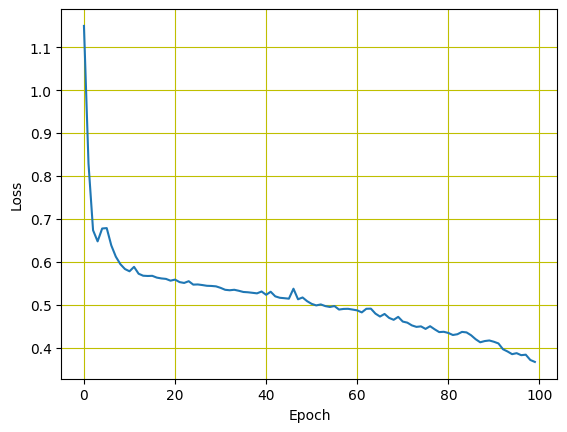

In [13]:
plt.plot(loss_arr)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid('True', color = 'y')
plt.show()